# Quantum Phase Estimation for a Controlled-Phase Gate
**Student:** Hanzala Anwar  
**Course:** Master's Quantum Computing  
**Exam project:** P2 - Quantum Phase Estimation

## 1. Installing and importing dependencies


In [1]:
%pip -q install "qiskit>=1.2,<2.0" "qiskit-aer>=0.15,<0.18" matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.8 MB/s eta 0:00:00


In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import MCPhaseGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.visualization import plot_histogram

## 2. Circuit construction

In [3]:
"""Reusable circuits and analysis helpers for controlled-phase QPE."""
from __future__ import annotations
import math
from collections import Counter
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import MCPhaseGate


def inverse_qft(qc: QuantumCircuit, qubits: list[int]) -> None:
    """Apply an inverse QFT with final swaps to qubits in little-endian order."""
    n = len(qubits)
    for i in range(n // 2):
        qc.swap(qubits[i], qubits[n - i - 1])
    for j in reversed(range(n)):
        for k in reversed(range(j + 1, n)):
            qc.cp(-math.pi / (2 ** (k - j)), qubits[k], qubits[j])
        qc.h(qubits[j])


def build_qpe_controlled_phase(phi: float, precision: int = 4, measure: bool = True) -> QuantumCircuit:
    """Estimate theta=phi/(2*pi) for U=CP(phi) and eigenstate |11>."""
    if precision < 1:
        raise ValueError("precision must be positive")
    count = QuantumRegister(precision, "count")
    target = QuantumRegister(2, "target")
    classical = ClassicalRegister(precision, "phase")
    qc = QuantumCircuit(count, target, classical if measure else None)

    qc.x(target[0]); qc.x(target[1])  # eigenstate |11>
    qc.h(count)
    for j in range(precision):
        gate = MCPhaseGate(phi * (2 ** j), num_ctrl_qubits=2)
        qc.append(gate, [count[j], target[0], target[1]])
    inverse_qft(qc, list(count))
    if measure:
        qc.measure(count, classical)
    return qc


def decode_counts(counts: dict[str, int], precision: int) -> tuple[float, str, float]:
    """Return mode estimate, modal bit string, and modal probability."""
    bitstring, shots = max(counts.items(), key=lambda item: item[1])
    theta = int(bitstring, 2) / (2 ** precision)
    probability = shots / sum(counts.values())
    return theta, bitstring, probability


def circular_error(theta_est: float, theta_true: float) -> float:
    d = abs(theta_est - theta_true)
    return min(d, 1.0 - d)

In [4]:
phi = 2 * np.pi * 3/8
qc = build_qpe_controlled_phase(phi, precision=4)
print(qc.draw(output="text", fold=120))

          ┌───┐                                                                                                        »
 count_0: ┤ H ├─■───────────────────────────────────X──────────────────────────────────────────■──────────────■────────»
          ├───┤ │                                   │                                          │        ┌───┐ │        »
 count_1: ┤ H ├─┼─────────■───────────────────X─────┼──────────────────────■─────────■─────────┼────────┤ H ├─┼────────»
          ├───┤ │         │                   │     │                ┌───┐ │         │P(-π/2)  │        └───┘ │P(-π/4) »
 count_2: ┤ H ├─┼─────────┼─────────■─────────X─────┼───────■────────┤ H ├─┼─────────■─────────┼──────────────■────────»
          ├───┤ │         │         │               │ ┌───┐ │P(-π/2) └───┘ │P(-π/4)            │P(-π/8)  ┌─┐           »
 count_3: ┤ H ├─┼─────────┼─────────┼───────■───────X─┤ H ├─■──────────────■───────────────────■─────────┤M├───────────»
          ├───┤ │         │     

## 3. Ideal simulation and phase decoding

Most likely bits: 1100
Estimated theta: 0.750000; true theta: 0.375000
Modal probability: 0.504


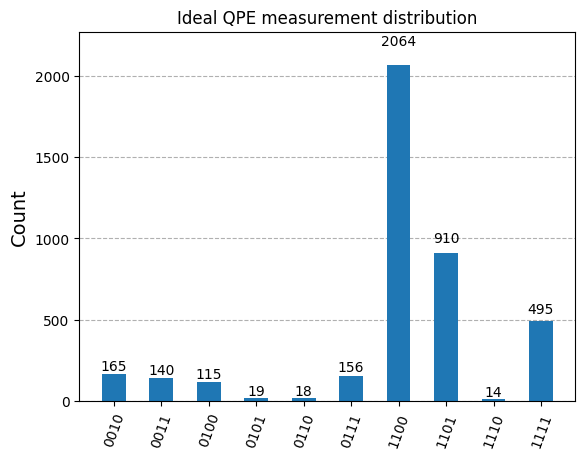

In [5]:
def run_counts(qc, shots=4096, noise_model=None, seed=7):
    """Transpile and execute a measured circuit, returning a non-empty counts dictionary."""
    backend = AerSimulator(noise_model=noise_model)
    transpile_options = {
        "backend": backend,
        "optimization_level": 1,
        "seed_transpiler": seed,
    }
    # With noise, force transpilation into the same basis gates used by the model.
    if noise_model is not None:
        transpile_options["basis_gates"] = noise_model.basis_gates

    tqc = transpile(qc, **transpile_options)
    result = backend.run(tqc, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts(tqc)
    if not counts:
        raise RuntimeError("Simulation completed but returned no measurement counts.")
    return counts

counts = run_counts(qc)
theta_est, bits, confidence = decode_counts(counts, precision=4)
print(f"Most likely bits: {bits}")
print(f"Estimated theta: {theta_est:.6f}; true theta: {3/8:.6f}")
print(f"Modal probability: {confidence:.3f}")
fig = plot_histogram(counts, title="Ideal QPE measurement distribution")
display(fig)


## 4. Experiments on exact and non-exact phases

In [6]:
phases = [1/8, 3/8, 5/16, 0.30]
rows = []
for theta_true in phases:
    m = 5
    circuit = build_qpe_controlled_phase(2*np.pi*theta_true, precision=m)
    c = run_counts(circuit)
    theta_est, bits, confidence = decode_counts(c, m)
    rows.append({
        "theta_true": theta_true,
        "precision_qubits": m,
        "modal_bits": bits,
        "theta_est": theta_est,
        "circular_error": circular_error(theta_est, theta_true),
        "modal_probability": confidence,
    })
pd.DataFrame(rows)

,theta_true,precision_qubits,modal_bits,theta_est,circular_error,modal_probability
0,0.1250,5,00100,0.12500,0.00000,0.185059
1,0.3750,5,11000,0.75000,0.37500,0.464600
2,0.3125,5,11011,0.84375,0.46875,0.269287
3,0.3000,5,01011,0.34375,0.04375,0.171143


Exact binary fractions concentrate on one output. A non-exact phase spreads probability around the nearest representable fractions, as predicted by the finite Fourier transform.

## 5. Precision study

,m,estimate,error,confidence
0,3,0.75000,0.45000,0.379150
1,4,0.75000,0.45000,0.238525
2,5,0.34375,0.04375,0.174194
3,6,0.34375,0.04375,0.118774
4,7,0.34375,0.04375,0.118774


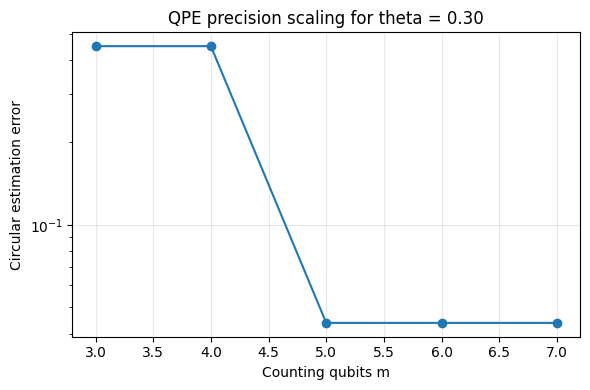

In [7]:
theta_true = 0.30
rows = []
for m in range(3, 8):
    circuit = build_qpe_controlled_phase(2*np.pi*theta_true, precision=m)
    c = run_counts(circuit, shots=8192)
    theta_est, bits, confidence = decode_counts(c, m)
    rows.append({"m": m, "estimate": theta_est,
                 "error": circular_error(theta_est, theta_true),
                 "confidence": confidence})
precision_df = pd.DataFrame(rows)
display(precision_df)
plt.figure(figsize=(6,4))
plt.plot(precision_df["m"], precision_df["error"], marker="o")
plt.yscale("log")
plt.xlabel("Counting qubits m")
plt.ylabel("Circular estimation error")
plt.title("QPE precision scaling for theta = 0.30")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("qpe_precision_scaling.png", dpi=180)
plt.show()

## 6. Noise sensitivity

Ideal (theta, bits, modal probability): (0.75, '11000', 0.464599609375)
Noisy (theta, bits, modal probability): (0.75, '11000', 0.27197265625)
Ideal total shots: 4096
Noisy total shots: 4096


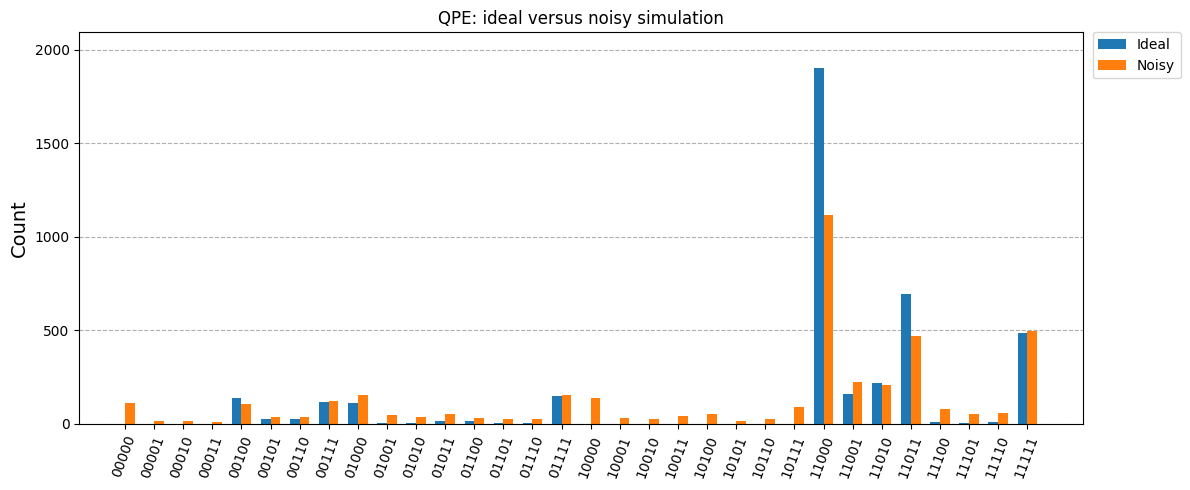

In [8]:
def simple_noise_model(p1=0.002, p2=0.015, readout=0.02):
    """Simple device-inspired model in a transpiler-compatible basis.

    RZ gates are treated as ideal virtual rotations. Depolarizing errors are
    attached to SX/X and CX gates, which are the basis produced by transpilation.
    """
    model = NoiseModel(basis_gates=["rz", "sx", "x", "cx"])
    model.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["sx", "x"])
    model.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx"])
    ro = ReadoutError([[1-readout, readout], [readout, 1-readout]])
    model.add_all_qubit_readout_error(ro)
    return model

theta_true = 3/8
m = 5
circuit = build_qpe_controlled_phase(2*np.pi*theta_true, precision=m)

ideal = run_counts(circuit, shots=4096)
noise_model = simple_noise_model()
noisy = run_counts(circuit, shots=4096, noise_model=noise_model)

ideal_est = decode_counts(ideal, m)
noisy_est = decode_counts(noisy, m)
print("Ideal (theta, bits, modal probability):", ideal_est)
print("Noisy (theta, bits, modal probability):", noisy_est)
print("Ideal total shots:", sum(ideal.values()))
print("Noisy total shots:", sum(noisy.values()))

# plot_histogram creates and returns its own Figure. Save that exact object;
# using plt.savefig() here can save an unrelated blank current figure in Colab.
fig = plot_histogram(
    [ideal, noisy],
    legend=["Ideal", "Noisy"],
    title="QPE: ideal versus noisy simulation",
    figsize=(12, 5),
    bar_labels=False,
)
fig.tight_layout()
fig.savefig("qpe_noise_comparison.png", dpi=180, bbox_inches="tight")
display(fig)


## 9. Conclusions
The implementation correctly estimates the eigenphase of the controlled-phase gate on the eigenstate $|11\rangle$. Increasing the counting-register size improves resolution, while realistic noise reduces peak concentration and makes circuit decomposition relevant to practical performance.